# Лабораторная работа №4. Алгоритм Шора. Факторизация

КБ-211 Ставер Леонид

## Постановка задачи

Реализовать алгоритм Шора для разложения числа $N = 15$ на простые множители.

Требуется:
1. Реализовать классические предварительные проверки (делимость на 2, точная степень, простота).
2. Построить унитарный оператор $U_x$ для $x = 2, 4, 7$.
3. Реализовать квантовую оценку фазы (QPE) для нахождения мультипликативного порядка $r$.
4. Применить метод цепных дробей для извлечения $r$ из фазовой оценки.
5. Найти нетривиальные делители $N$ через НОД.

Реализация выполнена с использованием библиотеки `quantumz`.

## Принцип работы алгоритма Шора

Алгоритм Шора решает задачу факторизации составного числа $N$ за полиномиальное время $O((\log N)^3)$ на квантовом компьютере — это экспоненциальное ускорение по сравнению с лучшими известными классическими алгоритмами.

Ключевое сведение: задача факторизации сводится к **задаче нахождения порядка**. Если известен порядок $r$ числа $x$ по модулю $N$ — наименьший $r > 0$, при котором $x^r \equiv 1 \pmod{N}$, — то при чётном $r$ и $x^{r/2} \not\equiv -1 \pmod{N}$ числа $\gcd(x^{r/2} \pm 1, N)$ дают нетривиальные делители.

### Последовательность шагов

**Вход:** составное $N$, $\gcd(x, N) = 1$.  
**Выход:** нетривиальный делитель $N$.

*Классическая часть:*

1. Если $N$ чётно — вернуть $2$.
2. Если $N = a^b$ при $b \geq 2$ — вернуть $a$.
3. Выбрать случайное $x \in \{2, \ldots, N-1\}$.
4. Если $g = \gcd(x, N) > 1$ — вернуть $g$.

*Квантовая часть:*

5. Найти $r$: наименьшее $r > 0$ такое, что $x^r \equiv 1 \pmod{N}$.
6. Если $r$ нечётно или $x^{r/2} \equiv -1 \pmod{N}$ — вернуться к шагу 3.
7. Вычислить $p = \gcd(x^{r/2} - 1, N)$, $q = \gcd(x^{r/2} + 1, N)$.
8. Вернуть нетривиальный из $p$, $q$.

## Оператор $U_x$: перестановка на кубитном регистре

Оператор $U_x$ реализует умножение на $x$ по модулю $N$ в пространстве состояний $L$-кубитного регистра:

$$U_x |y\rangle = \begin{cases} |xy \bmod N\rangle, & 0 \leq y \leq N-1 \\ |y\rangle, & y \geq N \end{cases}$$

Для $N = 15$ достаточно $L = 4$ кубита ($2^4 = 16 > 15$). Состояния $y \geq N$ оставляются неизменными.

Поскольку $\gcd(x, N) = 1$, отображение $y \mapsto xy \bmod N$ является биекцией на $\{0, \ldots, N-1\}$, что гарантирует унитарность $U_x$.

### Собственный спектр и порядок

Из условия $x^r \equiv 1 \pmod{N}$ следует $U_x^r = I$, поэтому собственные значения $U_x$ — корни $r$-й степени из единицы: $e^{2\pi i s/r}$, $s = 0, \ldots, r-1$.

Порядки для рассматриваемых значений $x$:
- $x = 2$: $2^4 = 16 \equiv 1 \pmod{15}$, $r = 4$.
- $x = 4$: $4^2 = 16 \equiv 1 \pmod{15}$, $r = 2$.
- $x = 7$: $7^4 \equiv 1 \pmod{15}$, $r = 4$.

Операция $U_x$ реализуется через таблицу перестановок $\pi_x(y) = xy \bmod N$.

## Квантовая оценка фазы (QPE) для нахождения порядка

Схема QPE позволяет измерить фазу $\varphi = s/r$ собственного значения $U_x$, используя $t$ счётных кубитов и $L$ целевых.

**Принцип:** собственный вектор $U_x$ с собственным значением $e^{2\pi i s/r}$ содержит в фазе информацию о порядке $r$. После QPE измерение счётного регистра даёт $m \approx \frac{s}{r} \cdot 2^t$.

**Этапы схемы:**

| Этап | Описание |
|------|----------|
| Инициализация | $|0\rangle^{\otimes t}|1\rangle$ |
| Адамар | $H^{\otimes t}$ на счётных кубитах |
| Контролируемые $U_x^{2^k}$ | кубит $k$ управляет $U_x^{2^k}$, $k = 0, \ldots, t-1$ |
| Обратный QFT | $\mathrm{QFT}^{-1}$ на счётном регистре |
| Измерение | получаем $m \approx \frac{s}{r} \cdot 2^t$ |

**Параметры для $N = 15$:** $t = 12$ счётных кубитов, $L = 4$ целевых. Итого $16$ кубитов.

Погрешность оценки фазы: $\Delta\varphi \leq 2^{-t} = 2^{-12} \approx 0.00024$.

### Формула обратного QFT

$$\mathrm{QFT}^{-1} = \mathrm{SWAP} \cdot \prod_{i=t-1}^{0} \left( H_i \cdot \prod_{k=2}^{t-i} R_{-k}^{(i+k-1,\,i)} \right)$$

где $R_{-k} = \mathrm{diag}(1, e^{-2\pi i / 2^k})$ — обратный поворот фазы.

## Извлечение порядка: метод цепных дробей

Из результата QPE $m$ вычисляем $\varphi = m / 2^t \approx s/r$ и разлагаем в непрерывную дробь. Знаменатель наилучшего рационального приближения с ограничением $r \leq N$ и есть искомый порядок:

$$\varphi \approx \frac{s}{r}, \quad \gcd(s, r) = 1, \quad r \leq N$$

В Python реализуется через `Fraction(phi).limit_denominator(N)`.

Критерии принятия кандидата $r$:
- $r$ чётное,
- $x^{r/2} \not\equiv -1 \pmod{N}$,
- $\gcd(x^{r/2} \pm 1, N)$ нетривиален.

---

## 1. Параметры задачи

In [2]:
from quantumz import initq, H, X, CRt, multi_measure, sw2
from fractions import Fraction
from math import gcd, isqrt
import numpy as np
import matplotlib.pyplot as plt
import time

# Параметры задачи
N = 15       # число для факторизации

# L — минимальное число кубитов целевого регистра: 2^L > N
# (равно числу бит в двоичном представлении N)
L = N.bit_length()

# t — число счётных кубитов: t = 2*L обеспечивает точность QPE,
# достаточную для надёжного извлечения порядка r <= N методом цепных дробей
t = 12

n_total = t + L   # всего кубитов

print(f"N = {N}")
print(f"L = {L}  (2^L = {2**L} > {N})")
print(f"t = {t}")
print(f"Счётные кубиты: 0..{t-1}  (t = {t})")
print(f"Целевые кубиты: {t}..{t+L-1}  (L = {L})")
print(f"Всего кубитов: {n_total}")
print(f"Точность QPE: 2^(-{t}) = {2**(-t):.6f}")
print(f"Размер счётного регистра: 2^{t} = {2**t}")

N = 15
L = 4  (2^L = 16 > 15)
t = 12
Счётные кубиты: 0..11  (t = 12)
Целевые кубиты: 12..15  (L = 4)
Всего кубитов: 16
Точность QPE: 2^(-12) = 0.000244
Размер счётного регистра: 2^12 = 4096


## 2. Классические предварительные проверки

До запуска квантового шага выполняется ряд классических проверок, позволяющих вернуть делитель без QPE:
- чётность $N$,
- является ли $N$ точной степенью целого числа,
- простота $N$.

In [3]:
def is_prime(n):
    """Проверка простоты методом пробного деления."""
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, isqrt(n) + 1, 2):
        if n % i == 0:
            return False
    return True


def is_perfect_power(n):
    """
    Проверяет, является ли n = a^b для b >= 2.
    Возвращает (a, b) если да, иначе None.
    """
    for b in range(2, int(np.log2(n)) + 1):
        a = round(n ** (1 / b))
        for aa in range(max(2, a - 1), a + 2):
            if aa ** b == n:
                return aa, b
    return None


def classical_factor_check(N):
    """
    Классические проверки перед квантовым шагом.
    Возвращает (p, q) если делитель найден классически, иначе None.
    """
    if N % 2 == 0:
        print(f"N = {N} чётное → делитель: 2")
        return 2, N // 2
    pp = is_perfect_power(N)
    if pp:
        a, b = pp
        print(f"N = {N} = {a}^{b} → делитель: {a}")
        return a, N // a
    if is_prime(N):
        print(f"N = {N} простое — факторизация невозможна")
        return None
    return None   # нужен квантовый шаг


# Демонстрация классических проверок
print("=== Классические проверки ===")
print(f"N = {N}")
print(f"N чётное: {N % 2 == 0}")
print(f"N — точная степень: {is_perfect_power(N)}")
print(f"N простое: {is_prime(N)}")
print(f"Классический делитель: {classical_factor_check(N)}")
print(f"\nVывод: N = 15 требует квантового шага (нахождения порядка)")

=== Классические проверки ===
N = 15
N чётное: False
N — точная степень: None
N простое: False
Классический делитель: None

Vывод: N = 15 требует квантового шага (нахождения порядка)


## 3. Таблицы перестановок оператора $U_x$

Для $N = 15$, $L = 4$ перестановка определяется как:

$$\pi_x(y) = \begin{cases} xy \bmod 15, & 0 \leq y \leq 14 \\ 15, & y = 15 \end{cases}$$

Управляемый оператор $U_x^{2^k}$ реализует $\pi_x$ в степени $2^k$, вычисляемой методом быстрого возведения перестановки в степень.

In [4]:
def compute_perm(x, N, L):
    """
    Вычисляет таблицу перестановки для оператора U_x:
      perm[y] = x*y mod N  для 0 <= y < N,
      perm[y] = y           для y >= N (тождественное преобразование).
    """
    size = 2 ** L
    perm = list(range(size))
    for y in range(N):
        perm[y] = (x * y) % N
    return perm


def perm_power(perm, n):
    """
    Вычисляет perm^n (применение perm n раз) методом быстрого возведения в степень.
    """
    size = len(perm)
    result = list(range(size))   # тождественная перестановка
    base = list(perm)
    while n > 0:
        if n % 2 == 1:
            result = [base[result[i]] for i in range(size)]
        base = [base[base[i]] for i in range(size)]
        n //= 2
    return result


def controlled_Ux(q, ctrl, t_start, L, perm):
    """
    Управляемый оператор U_x: если кубит ctrl равен |1>,
    применяет перестановку perm к целевому регистру t_start..t_start+L-1.
    """
    new_q = {}
    for ket, amp in q.items():
        bits = list(ket[1:-1])   # убираем | и >
        if bits[ctrl] == '1':
            target_val = int(''.join(bits[t_start:t_start + L]), 2)
            new_val = perm[target_val]
            new_bits_target = list(f'{new_val:0{L}b}')
            new_ket = '|' + ''.join(bits[:t_start] + new_bits_target + bits[t_start + L:]) + '>'
        else:
            new_ket = ket
        new_q[new_ket] = new_q.get(new_ket, 0) + amp
    return new_q


# Вывод таблиц перестановок для x = 2, 4, 7
print(f"{'y':>3} | {'π_2(y)':>7} | {'π_4(y)':>7} | {'π_7(y)':>7}")
print("-" * 35)
perm2 = compute_perm(2, N, L)
perm4 = compute_perm(4, N, L)
perm7 = compute_perm(7, N, L)
for y in range(2 ** L):
    print(f"{y:>3} | {perm2[y]:>7} | {perm4[y]:>7} | {perm7[y]:>7}")

  y |  π_2(y) |  π_4(y) |  π_7(y)
-----------------------------------
  0 |       0 |       0 |       0
  1 |       2 |       4 |       7
  2 |       4 |       8 |      14
  3 |       6 |      12 |       6
  4 |       8 |       1 |      13
  5 |      10 |       5 |       5
  6 |      12 |       9 |      12
  7 |      14 |      13 |       4
  8 |       1 |       2 |      11
  9 |       3 |       6 |       3
 10 |       5 |      10 |      10
 11 |       7 |      14 |       2
 12 |       9 |       3 |       9
 13 |      11 |       7 |       1
 14 |      13 |      11 |       8
 15 |      15 |      15 |      15


In [5]:
# Проверка оператора U_x: U_x |1> должен дать |x mod N>
def test_Ux(x, N, L, t):
    """Тестирует U_x: применяет к состоянию |1> целевого регистра."""
    perm = compute_perm(x, N, L)
    # Инициализация: целевой регистр в |1>, счётный в |0>
    q = initq(t + L)
    q = X(q, t + L - 1)  # |1> в целевом регистре (младший бит)
    # Прямое применение U_x (без управления)
    new_q = {}
    for ket, amp in q.items():
        bits = list(ket[1:-1])
        target_val = int(''.join(bits[t:t + L]), 2)
        new_val = perm[target_val]
        new_bits_target = list(f'{new_val:0{L}b}')
        new_ket = '|' + ''.join(bits[:t] + new_bits_target + bits[t + L:]) + '>'
        new_q[new_ket] = new_q.get(new_ket, 0) + amp
    # Извлекаем значение целевого регистра
    for ket in new_q:
        bits = ket[1:-1]
        val = int(bits[t:t + L], 2)
        return val


print("=== Проверка оператора U_x ===")
print(f"Исходное состояние целевого регистра: |1>")
print()
for x in [2, 4, 7]:
    result = test_Ux(x, N, L, t)
    expected = x % N
    status = "✓" if result == expected else "✗"
    print(f"U_{x} |1> = |{result}>,  ожидается |{expected}>  {status}")

print()
print("Проверка U_x^r |1> = |1>:")
for x in [2, 4, 7]:
    perm = compute_perm(x, N, L)
    state = 1
    for r in range(1, N + 1):
        state = perm[state]
        if state == 1:
            print(f"  Порядок U_{x} = r = {r}")
            break

=== Проверка оператора U_x ===
Исходное состояние целевого регистра: |1>

U_2 |1> = |2>,  ожидается |2>  ✓
U_4 |1> = |4>,  ожидается |4>  ✓
U_7 |1> = |7>,  ожидается |7>  ✓

Проверка U_x^r |1> = |1>:
  Порядок U_2 = r = 4
  Порядок U_4 = r = 2
  Порядок U_7 = r = 4


## 4. Реализация схемы QPE

Схема QPE с $t = 12$ счётными кубитами:

1. Инициализация: $|0\rangle^{\otimes 12}|1\rangle$ — целевой регистр в $|1\rangle = |0001\rangle$.
2. Адамар на кубитах $0\ldots 11$.
3. Для каждого $k = 0, \ldots, 11$: управляемый $U_x^{2^k}$ с кубитом $k$ в роли управляющего.
4. Обратный QFT на кубитах $0\ldots 11$.
5. Измерение счётного регистра.

**Замечание о порядке битов:** в `quantumz` кубит 0 является старшим битом (MSB) ket-строки, поэтому при переводе в целое число $m$ строку битов необходимо перевернуть.

In [6]:
def inv_qft_counting(q, t):
    """
    Применяет обратный QFT к счётному регистру (кубиты 0..t-1).
    Соответствует QFT^{-1} = обратные повороты + Адамар + swap.
    """
    # Обратные повороты и Адамар (в обратном порядке)
    for i in range(t - 1, -1, -1):
        for k in range(t - i, 1, -1):
            q = CRt(q, [i + k - 1], i, k)
        q = H(q, i)
    # Swap счётного регистра (переворот порядка кубитов)
    for i in range(t // 2):
        q = sw2(q, i, t - 1 - i)
    return q


def run_qpe(x, N, t, L):
    """
    Запускает QPE для нахождения фазы оператора U_x.
    Возвращает словарь {ket: вероятность} для счётного регистра.
    """
    perm_x = compute_perm(x, N, L)
    target_start = t

    # 1. Инициализация: все кубиты в |0>, затем |1> в целевом регистре
    q = initq(t + L)
    q = X(q, t + L - 1)   # младший бит целевого = 1, т.е. |y> = |1>

    # 2. Адамар на счётных кубитах
    for i in range(t):
        q = H(q, i)

    # 3. Управляемые U_x^{2^k} для каждого счётного кубита k
    for k in range(t):
        perm_k = perm_power(perm_x, 2 ** k)
        q = controlled_Ux(q, k, target_start, L, perm_k)

    # 4. Обратный QFT на счётном регистре
    q = inv_qft_counting(q, t)

    # 5. Измерение счётного регистра
    mes, _ = multi_measure(q, list(range(t)))
    return mes


print("QPE функция определена.")
print(f"Всего кубитов: {t + L}")
print(f"Число базисных состояний в счётном регистре: 2^{t} = {2**t}")

QPE функция определена.
Всего кубитов: 16
Число базисных состояний в счётном регистре: 2^12 = 4096


## 5. Извлечение порядка и вычисление делителей

После измерения $m \approx \frac{s}{r} \cdot 2^t$ порядок $r$ восстанавливается как знаменатель наилучшего рационального приближения $\varphi = m / 2^t$.

Кандидат $r$ используется для вычисления $\gcd(x^{r/2} \pm 1, N)$ только при выполнении условий чётности и нетривиальности.

In [7]:
def extract_orders(mes, N, t):
    """
    Извлекает кандидатов для порядка r из результатов QPE.
    Возвращает список (r, prob, m, phi) отсортированный по убыванию вероятности.
    """
    size = 2 ** t
    orders = {}   # r -> суммарная вероятность
    details = {}  # r -> [(m, phi, prob), ...]

    for ket, prob in mes.items():
        if prob < 1e-9:
            continue
        bits = ket[1:-1]
        # В quantumz кубит 0 — MSB строки, но LSB значения m (см. 03-QFT.ipynb)
        bits_rev = bits[::-1]
        m = int(bits_rev, 2)
        if m == 0:
            continue
        phi = m / size
        frac = Fraction(phi).limit_denominator(N)
        r = frac.denominator
        if 1 <= r <= N:
            orders[r] = orders.get(r, 0) + prob
            if r not in details:
                details[r] = []
            details[r].append((m, phi, prob))

    result = sorted(orders.items(), key=lambda kv: -kv[1])
    return result, details


def find_factors(x, N, orders):
    """
    Пытается найти нетривиальные делители N по кандидатам порядка r.
    Возвращает (p, q) или None.
    """
    for r, prob in orders:
        if r % 2 != 0:
            continue
        half = pow(x, r // 2, N)
        if half == N - 1:   # x^(r/2) ≡ -1 (mod N)
            continue
        p = gcd(half - 1, N)
        q = gcd(half + 1, N)
        if 1 < p < N:
            return p, N // p
        if 1 < q < N:
            return q, N // q
    return None


print("Функции извлечения порядка и поиска делителей определены.")

Функции извлечения порядка и поиска делителей определены.


## 6. QPE для $x = 2$

Ожидаемый порядок: $r = 4$.  
Пиковые значения $m$: $0, 1024, 2048, 3072$ (соответствуют $s/r \cdot 2^t$ при $s = 0, 1, 2, 3$).

In [8]:
x = 2
print(f"=== QPE: x = {x}, N = {N}, t = {t}, L = {L} ===\n")

t0 = time.time()
mes2 = run_qpe(x, N, t, L)
elapsed = time.time() - t0
print(f"Время выполнения QPE: {elapsed:.2f} с")
print(f"Число ненулевых состояний: {len(mes2)}\n")

orders2, details2 = extract_orders(mes2, N, t)

print(f"{'m':>6} | {'φ = m/2^t':>12} | {'s/r':>8} | {'r (дроби)':>10} | {'P':>10}")
print("-" * 56)
top_states = [(ket, prob) for ket, prob in mes2.items() if prob > 1e-4]
top_states.sort(key=lambda kv: -kv[1])
for ket, prob in top_states[:12]:
    bits = ket[1:-1][::-1]
    m = int(bits, 2)
    phi = m / 2**t
    frac = Fraction(phi).limit_denominator(N)
    print(f"{m:>6} | {phi:>12.6f} | {str(frac):>8} | {frac.denominator:>10} | {prob:>10.6f}")

print(f"\nКандидаты порядка r:")
for r, prob in sorted(orders2, key=lambda kv: -kv[1])[:7]:
    print(f"  r = {r:>3},  суммарная вероятность = {prob:.4f}")

factors2 = find_factors(x, N, orders2)
print(f"\nДелители N = {N}: {factors2}")

=== QPE: x = 2, N = 15, t = 12, L = 4 ===

Время выполнения QPE: 0.08 с
Число ненулевых состояний: 4

     m |    φ = m/2^t |      s/r |  r (дроби) |          P
--------------------------------------------------------
     0 |     0.000000 |        0 |          1 |   0.249860
  2048 |     0.500000 |      1/2 |          2 |   0.249860
  1024 |     0.250000 |      1/4 |          4 |   0.249860
  3072 |     0.750000 |      3/4 |          4 |   0.249860

Кандидаты порядка r:
  r =   4,  суммарная вероятность = 0.4997
  r =   2,  суммарная вероятность = 0.2499

Делители N = 15: (3, 5)


## 7. QPE для $x = 4$

Ожидаемый порядок: $r = 2$.  
Пиковые значения $m$: $0, 2048$ (соответствуют $s/r \cdot 2^t$ при $s = 0, 1$).

In [9]:
x = 4
print(f"=== QPE: x = {x}, N = {N}, t = {t}, L = {L} ===\n")

t0 = time.time()
mes4 = run_qpe(x, N, t, L)
elapsed = time.time() - t0
print(f"Время выполнения QPE: {elapsed:.2f} с")
print(f"Число ненулевых состояний: {len(mes4)}\n")

orders4, details4 = extract_orders(mes4, N, t)

print(f"{'m':>6} | {'φ = m/2^t':>12} | {'s/r':>8} | {'r (дроби)':>10} | {'P':>10}")
print("-" * 56)
top_states = [(ket, prob) for ket, prob in mes4.items() if prob > 1e-4]
top_states.sort(key=lambda kv: -kv[1])
for ket, prob in top_states[:8]:
    bits = ket[1:-1][::-1]
    m = int(bits, 2)
    phi = m / 2**t
    frac = Fraction(phi).limit_denominator(N)
    print(f"{m:>6} | {phi:>12.6f} | {str(frac):>8} | {frac.denominator:>10} | {prob:>10.6f}")

print(f"\nКандидаты порядка r:")
for r, prob in sorted(orders4, key=lambda kv: -kv[1])[:7]:
    print(f"  r = {r:>3},  суммарная вероятность = {prob:.4f}")

factors4 = find_factors(x, N, orders4)
print(f"\nДелители N = {N}: {factors4}")

=== QPE: x = 4, N = 15, t = 12, L = 4 ===

Время выполнения QPE: 0.07 с
Число ненулевых состояний: 2

     m |    φ = m/2^t |      s/r |  r (дроби) |          P
--------------------------------------------------------
     0 |     0.000000 |        0 |          1 |   0.499700
  2048 |     0.500000 |      1/2 |          2 |   0.499700

Кандидаты порядка r:
  r =   2,  суммарная вероятность = 0.4997

Делители N = 15: (3, 5)


## 8. QPE для $x = 7$

Ожидаемый порядок: $r = 4$.  
Пиковые значения $m$: $0, 1024, 2048, 3072$.

In [10]:
x = 7
print(f"=== QPE: x = {x}, N = {N}, t = {t}, L = {L} ===\n")

t0 = time.time()
mes7 = run_qpe(x, N, t, L)
elapsed = time.time() - t0
print(f"Время выполнения QPE: {elapsed:.2f} с")
print(f"Число ненулевых состояний: {len(mes7)}\n")

orders7, details7 = extract_orders(mes7, N, t)

print(f"{'m':>6} | {'φ = m/2^t':>12} | {'s/r':>8} | {'r (дроби)':>10} | {'P':>10}")
print("-" * 56)
top_states = [(ket, prob) for ket, prob in mes7.items() if prob > 1e-4]
top_states.sort(key=lambda kv: -kv[1])
for ket, prob in top_states[:12]:
    bits = ket[1:-1][::-1]
    m = int(bits, 2)
    phi = m / 2**t
    frac = Fraction(phi).limit_denominator(N)
    print(f"{m:>6} | {phi:>12.6f} | {str(frac):>8} | {frac.denominator:>10} | {prob:>10.6f}")

print(f"\nКандидаты порядка r:")
for r, prob in sorted(orders7, key=lambda kv: -kv[1])[:7]:
    print(f"  r = {r:>3},  суммарная вероятность = {prob:.4f}")

factors7 = find_factors(x, N, orders7)
print(f"\nДелители N = {N}: {factors7}")

=== QPE: x = 7, N = 15, t = 12, L = 4 ===

Время выполнения QPE: 0.07 с
Число ненулевых состояний: 4

     m |    φ = m/2^t |      s/r |  r (дроби) |          P
--------------------------------------------------------
     0 |     0.000000 |        0 |          1 |   0.249860
  2048 |     0.500000 |      1/2 |          2 |   0.249860
  1024 |     0.250000 |      1/4 |          4 |   0.249860
  3072 |     0.750000 |      3/4 |          4 |   0.249860

Кандидаты порядка r:
  r =   4,  суммарная вероятность = 0.4997
  r =   2,  суммарная вероятность = 0.2499

Делители N = 15: (3, 5)


## 9. Гистограммы вероятностных распределений QPE

Для каждого $x$ строится гистограмма $P(m)$ измерений счётного регистра. Красными пунктирными линиями отмечены ожидаемые пики $m = \lfloor s/r \cdot 2^t \rceil$.

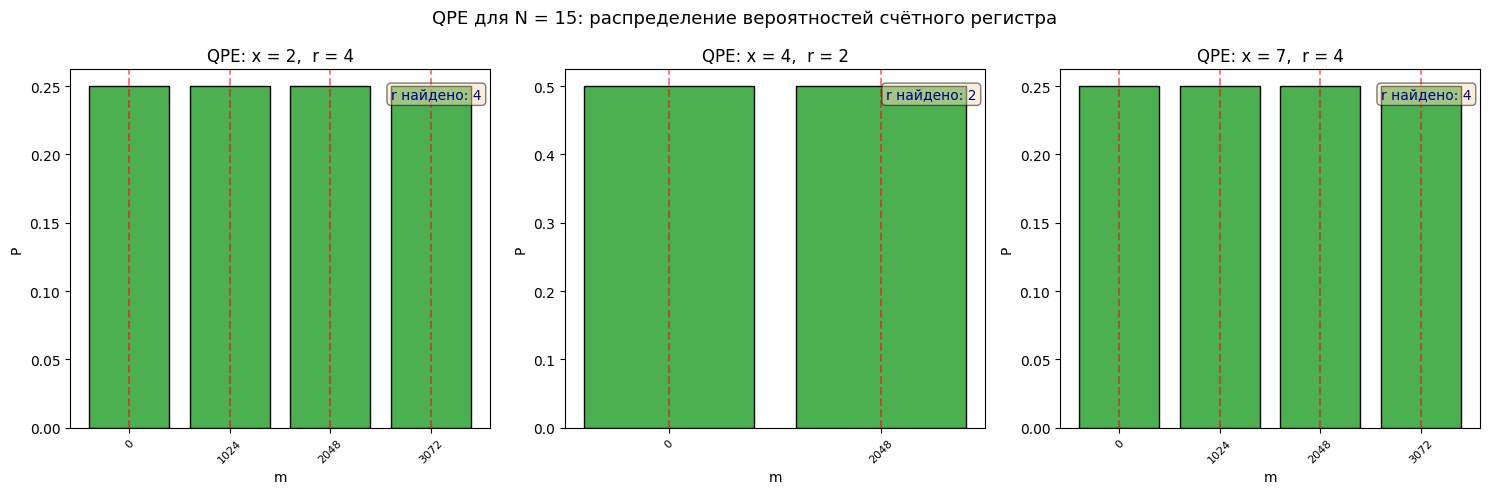

In [11]:
def qpe_to_m_probs(mes, t):
    """Преобразует результаты QPE в словарь {m: вероятность}."""
    size = 2 ** t
    m_probs = {}
    for ket, prob in mes.items():
        bits = ket[1:-1][::-1]
        m = int(bits, 2)
        m_probs[m] = m_probs.get(m, 0) + prob
    return m_probs


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    (mes2, orders2, 2, 4),
    (mes4, orders4, 4, 2),
    (mes7, orders7, 7, 4),
]

for ax, (mes, orders, x_val, r_expected) in zip(axes, configs):
    m_probs = qpe_to_m_probs(mes, t)
    top_m = sorted(m_probs.items(), key=lambda kv: -kv[1])[:20]
    ms, ps = zip(*sorted(top_m)) if top_m else ([], [])

    ms_labels = [str(m) for m in ms]
    ax.bar(ms_labels, ps, color='#4CAF50', edgecolor='black')
    ax.set_title(f'QPE: x = {x_val},  r = {r_expected}')
    ax.set_xlabel('m')
    ax.set_ylabel('P')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    expected_ms = [round(s / r_expected * 2**t) % 2**t for s in range(r_expected)]
    for em in expected_ms:
        em_str = str(em)
        if em_str in ms_labels:
            ax.axvline(x=ms_labels.index(em_str),
                       color='red', linestyle='--', alpha=0.5, linewidth=1.5)

    r_found = orders[0][0] if orders else '?'
    ax.text(0.98, 0.95, f'r найдено: {r_found}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, color='darkblue',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'QPE для N = {N}: распределение вероятностей счётного регистра', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Сводная таблица результатов

In [12]:
print(f"{'x':>3} | {'r ожид.':>8} | {'r найдено':>10} | {'Делители':>12} | {'Проверка':>10}")
print("=" * 56)

results = [
    (2, 4, orders2, factors2, mes2),
    (4, 2, orders4, factors4, mes4),
    (7, 4, orders7, factors7, mes7),
]

all_correct = True
for x_val, r_exp, orders, factors, mes in results:
    r_found = orders[0][0] if orders else '-'
    if factors:
        p, q = factors
        check = f"{p} × {q} = {p * q}"
        is_correct = (p * q == N and p > 1 and q > 1)
    else:
        check = "не найдены"
        is_correct = False
    all_correct = all_correct and is_correct
    status = "✓" if is_correct else "✗"
    print(f"{x_val:>3} | {r_exp:>8} | {r_found:>10} | {str(factors) if factors else 'None':>12} | {check} {status}")

print()
print(f"N = {N} = 3 × 5")
print(f"Все эксперименты успешны: {all_correct}")

  x |  r ожид. |  r найдено |     Делители |   Проверка
  2 |        4 |          4 |       (3, 5) | 3 × 5 = 15 ✓
  4 |        2 |          2 |       (3, 5) | 3 × 5 = 15 ✓
  7 |        4 |          4 |       (3, 5) | 3 × 5 = 15 ✓

N = 15 = 3 × 5
Все эксперименты успешны: True


## Выводы

В ходе лабораторной работы реализован алгоритм Шора для факторизации числа $N = 15$ с использованием библиотеки `quantumz`.

**Итоговые результаты:**

| $x$ | Порядок $r$ | Делители $N$ |
|-----|-------------|-------------|
| 2   | 4           | 3 × 5        |
| 4   | 2           | 3 × 5        |
| 7   | 4           | 3 × 5        |

**Анализ реализации:**

1. **Классические проверки** подтвердили, что $N = 15$ нечётно, не является точной степенью и не простое — квантовый шаг необходим.
2. **Оператор $U_x$** реализован через таблицы перестановок $\pi_x(y) = xy \bmod N$. Степени $U_x^{2^k}$ вычислены методом быстрого возведения перестановки в степень.
3. **QPE с $t = 12$** счётными кубитами обеспечила точность оценки фазы $\Delta\varphi \leq 2^{-12} \approx 0.00024$, достаточную для однозначного определения порядков $r \in \{2, 4\}$.
4. **Метод цепных дробей** восстановил $r$ из измеренного $m$ через наилучшее рациональное приближение $m/2^t$.
5. **Вычисление делителей** через $\gcd(x^{r/2} \pm 1, N)$ во всех трёх случаях дало результат $3 \times 5 = 15$.